# Paso 04 -- Entrenar un agente PPO (Stable-Baselines3) sobre la instancia chica

Conecta un agente de RL (PPO, no DQN -- el DQN de SB3 no soporta
`MultiDiscrete` de forma nativa, PPO si) sobre `EntornoDemandaAleatoria`
(`simulacion/src/entrenamiento.py`), que regenera la demanda en cada
`reset()` en vez de reusar una tabla fija -- necesario para que el agente
no memorice una unica realizacion de demanda (ver el modulo y
`simulacion/README.md`).

**Instancia de entrenamiento:** los parametros de `escalon_1` (franja
manana, 2 barcos, pocos grupos) -- la instancia chica, para verificar
rapido que el agente aprende algo antes de escalar a instancias mas
grandes. Los hiperparametros (semilla de entrenamiento, timesteps totales)
viven en `simulacion/config/instance.yaml` -> `agente.entrenamiento`.

**Orden:** construir el entorno -> `check_env` (chequeo estandar de SB3,
antes de entrenar) -> entrenar -> guardar el modelo y la curva de
recompensa por episodio (para confirmar a ojo si sube).


In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import yaml

BASE_DIR = Path.cwd().parent
BB_DIR = (BASE_DIR / "../bergen-boats").resolve()
DEMAND_DIR = (BASE_DIR / "../demand").resolve()
sys.path.insert(0, str(DEMAND_DIR / "src"))
sys.path.insert(0, str(BASE_DIR / "src"))

import masas as demand_masas
import llegadas as demand_llegadas
from entrenamiento import EntornoDemandaAleatoria

cfg_sim = yaml.safe_load(open(BASE_DIR / "config" / "instance.yaml", encoding="utf-8"))
cfg_bb = yaml.safe_load(open(BB_DIR / "config" / "instance.yaml", encoding="utf-8"))
cfg_demand = demand_masas.cargar_config(DEMAND_DIR / "config" / "instance.yaml")

resumen_masas = pd.read_csv(DEMAND_DIR / "output" / "masas_por_nodo.csv", index_col="id")
intensidad_od = pd.read_csv(DEMAND_DIR / "output" / "matriz_intensidad_od.csv")
poblacion_total_zonas = resumen_masas["poblacion_total"].sum()
conexiones_fuertes = cfg_bb["garantia"]["conexiones_fuertes"]

nodos = [n["id"] for n in cfg_bb["nodos_demanda"]]
matriz_tiempos = pd.read_csv(BB_DIR / "02_ruteo_navegable" / "output" / "matriz_tiempos_min.csv", index_col=0)

cfg_agente = cfg_sim["agente"]
cfg_entren = cfg_agente["entrenamiento"]
cfg_escalon = cfg_sim["escalones"][cfg_entren["escalon_base"]]
hora_ini_min, hora_fin_min = cfg_escalon["horas"][0] * 60, cfg_escalon["horas"][1] * 60

OUT_DIR = BASE_DIR / "output" / "rl_ppo"
OUT_DIR.mkdir(parents=True, exist_ok=True)


def construir_entorno_entrenamiento(semilla_entrenamiento):
    return EntornoDemandaAleatoria(
        generar_llegadas_dia_fn=demand_llegadas.generar_llegadas_dia,
        cfg_demand=cfg_demand, intensidad_od=intensidad_od, conexiones_fuertes=conexiones_fuertes,
        poblacion_total_zonas=poblacion_total_zonas, horas=cfg_escalon["horas"],
        porcentaje_poblacion_dia=cfg_escalon["porcentaje_poblacion_dia"],
        semilla_entrenamiento=semilla_entrenamiento,
        matriz_tiempos=matriz_tiempos, nodos=nodos, num_barcos=cfg_escalon["num_barcos"],
        capacidad_barco=cfg_bb["flota"]["capacidad_pasajeros"], nodo_inicial=cfg_bb["flota"]["nodo_inicial"],
        paso_tiempo_min=cfg_sim["paso_tiempo_min"], hora_inicio_min=hora_ini_min, hora_fin_min=hora_fin_min,
        cfg_recompensa=cfg_sim["recompensa"], unidad_demanda=cfg_sim["unidad_demanda"],
    )


print(f"Instancia de entrenamiento: {cfg_entren['escalon_base']} "
      f"({cfg_escalon['num_barcos']} barcos, {cfg_escalon['horas']}h, "
      f"{cfg_escalon['porcentaje_poblacion_dia']*100:.1f}% poblacion/dia)")
print(f"Semilla de entrenamiento (raiz de la secuencia de demandas): {cfg_entren['semilla_entrenamiento']}")
print(f"Total timesteps: {cfg_entren['total_timesteps']}")


Instancia de entrenamiento: escalon_1 (2 barcos, [6, 9]h, 0.8% poblacion/dia)
Semilla de entrenamiento (raiz de la secuencia de demandas): 123
Total timesteps: 100000


## Confirmar demanda fresca por reset (antes de entrenar)

Dos `reset()` sin semilla deben dar demandas distintas; dos `reset(seed=42)`
deben dar la misma -- el mecanismo que hace posible el entrenamiento
Montecarlo (ver `entrenamiento.py`).

In [2]:
env_check = construir_entorno_entrenamiento(semilla_entrenamiento=cfg_entren["semilla_entrenamiento"])

env_check.reset(seed=42)
n_a = len(env_check.grupos_df)
env_check.reset(seed=42)
n_b = len(env_check.grupos_df)
env_check.reset()
n_c = len(env_check.grupos_df)
env_check.reset()
n_d = len(env_check.grupos_df)

print(f"reset(seed=42) dos veces: {n_a} y {n_b} grupos -- iguales: {n_a == n_b}")
print(f"reset() sin semilla dos veces: {n_c} y {n_d} grupos -- distintos: {n_c != n_d}")
assert n_a == n_b, "reset(seed=X) deberia ser reproducible"
assert n_c != n_d, "reset() sin semilla deberia dar demandas distintas"
print("\nOK: demanda fresca por reset confirmada.")


reset(seed=42) dos veces: 23 y 23 grupos -- iguales: True
reset() sin semilla dos veces: 20 y 25 grupos -- distintos: True

OK: demanda fresca por reset confirmada.


## `check_env` (chequeo estandar de SB3, antes de entrenar)

In [3]:
from stable_baselines3.common.env_checker import check_env

env_para_chequear = construir_entorno_entrenamiento(semilla_entrenamiento=cfg_entren["semilla_entrenamiento"])
check_env(env_para_chequear, warn=True)
print("OK: check_env no encontro problemas.")


OK: check_env no encontro problemas.


## Entrenar PPO

`Monitor` envuelve el entorno para registrar recompensa/duracion por
episodio en un CSV (`output/rl_ppo/monitor.monitor.csv`), sin depender de
TensorBoard -- se grafica directamente con matplotlib mas abajo.

In [4]:
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor

env_entrenamiento = construir_entorno_entrenamiento(semilla_entrenamiento=cfg_entren["semilla_entrenamiento"])
env_monitor = Monitor(env_entrenamiento, filename=str(OUT_DIR / "monitor"))

model = PPO(
    "MlpPolicy", env_monitor,
    gamma=cfg_agente["gamma"],
    seed=cfg_entren["semilla_entrenamiento"],
    verbose=1,
)
model.learn(total_timesteps=cfg_entren["total_timesteps"])


Using cpu device
Wrapping the env in a DummyVecEnv.


----------------------------------
| rollout/           |           |
|    ep_len_mean     | 90        |
|    ep_rew_mean     | -2.88e+03 |
| time/              |           |
|    fps             | 232       |
|    iterations      | 1         |
|    time_elapsed    | 8         |
|    total_timesteps | 2048      |
----------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 90          |
|    ep_rew_mean          | -3.06e+03   |
| time/                   |             |
|    fps                  | 203         |
|    iterations           | 2           |
|    time_elapsed         | 20          |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.004691398 |
|    clip_fraction        | 0.0107      |
|    clip_range           | 0.2         |
|    entropy_loss         | -3.22       |
|    explained_variance   | -0.00024    |
|    learning_rate        | 0.0003      |
|    loss                 | 1.87e+05    |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.00823    |
|    value_loss           | 3.46e+05    |
-----------------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 90          |
|    ep_rew_mean          | -2.99e+03   |
| time/                   |             |
|    fps                  | 204         |
|    iterations           | 3           |
|    time_elapsed         | 29          |
|    total_timesteps      | 6144        |
| train/                  |             |
|    approx_kl            | 0.004039107 |
|    clip_fraction        | 0.00986     |
|    clip_range           | 0.2         |
|    entropy_loss         | -3.21       |
|    explained_variance   | 0.00062     |
|    learning_rate        | 0.0003      |
|    loss                 | 2.32e+05    |
|    n_updates            | 20          |
|    policy_gradient_loss | -0.00606    |
|    value_loss           | 4.45e+05    |
-----------------------------------------


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 90           |
|    ep_rew_mean          | -2.99e+03    |
| time/                   |              |
|    fps                  | 207          |
|    iterations           | 4            |
|    time_elapsed         | 39           |
|    total_timesteps      | 8192         |
| train/                  |              |
|    approx_kl            | 0.0038882052 |
|    clip_fraction        | 0.00796      |
|    clip_range           | 0.2          |
|    entropy_loss         | -3.2         |
|    explained_variance   | 0.000321     |
|    learning_rate        | 0.0003       |
|    loss                 | 1.32e+05     |
|    n_updates            | 30           |
|    policy_gradient_loss | -0.0057      |
|    value_loss           | 3.22e+05     |
------------------------------------------


...

------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 90           |
|    ep_rew_mean          | -2.19e+03    |
| time/                   |              |
|    fps                  | 211          |
|    iterations           | 45           |
|    time_elapsed         | 436          |
|    total_timesteps      | 92160        |
| train/                  |              |
|    approx_kl            | 0.0049363584 |
|    clip_fraction        | 0.0148       |
|    clip_range           | 0.2          |
|    entropy_loss         | -3.01        |
|    explained_variance   | 1.79e-07     |
|    learning_rate        | 0.0003       |
|    loss                 | 6.46e+04     |
|    n_updates            | 440          |
|    policy_gradient_loss | -0.0099      |
|    value_loss           | 1.32e+05     |
------------------------------------------


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 90           |
|    ep_rew_mean          | -2.16e+03    |
| time/                   |              |
|    fps                  | 211          |
|    iterations           | 46           |
|    time_elapsed         | 445          |
|    total_timesteps      | 94208        |
| train/                  |              |
|    approx_kl            | 0.0028258867 |
|    clip_fraction        | 4.88e-05     |
|    clip_range           | 0.2          |
|    entropy_loss         | -2.98        |
|    explained_variance   | 1.19e-07     |
|    learning_rate        | 0.0003       |
|    loss                 | 9.4e+04      |
|    n_updates            | 450          |
|    policy_gradient_loss | -0.00571     |
|    value_loss           | 2.01e+05     |
------------------------------------------


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 90           |
|    ep_rew_mean          | -2.06e+03    |
| time/                   |              |
|    fps                  | 211          |
|    iterations           | 47           |
|    time_elapsed         | 455          |
|    total_timesteps      | 96256        |
| train/                  |              |
|    approx_kl            | 0.0046405997 |
|    clip_fraction        | 0.00635      |
|    clip_range           | 0.2          |
|    entropy_loss         | -2.97        |
|    explained_variance   | 2.38e-07     |
|    learning_rate        | 0.0003       |
|    loss                 | 7.6e+04      |
|    n_updates            | 460          |
|    policy_gradient_loss | -0.00778     |
|    value_loss           | 1.5e+05      |
------------------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 90          |
|    ep_rew_mean          | -2.02e+03   |
| time/                   |             |
|    fps                  | 211         |
|    iterations           | 48          |
|    time_elapsed         | 464         |
|    total_timesteps      | 98304       |
| train/                  |             |
|    approx_kl            | 0.005975232 |
|    clip_fraction        | 0.0187      |
|    clip_range           | 0.2         |
|    entropy_loss         | -2.99       |
|    explained_variance   | 2.38e-07    |
|    learning_rate        | 0.0003      |
|    loss                 | 6.15e+04    |
|    n_updates            | 470         |
|    policy_gradient_loss | -0.00876    |
|    value_loss           | 9.96e+04    |
-----------------------------------------


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 90           |
|    ep_rew_mean          | -2.05e+03    |
| time/                   |              |
|    fps                  | 211          |
|    iterations           | 49           |
|    time_elapsed         | 473          |
|    total_timesteps      | 100352       |
| train/                  |              |
|    approx_kl            | 0.0051661497 |
|    clip_fraction        | 0.0123       |
|    clip_range           | 0.2          |
|    entropy_loss         | -2.95        |
|    explained_variance   | 1.79e-07     |
|    learning_rate        | 0.0003       |
|    loss                 | 6.33e+04     |
|    n_updates            | 480          |
|    policy_gradient_loss | -0.00777     |
|    value_loss           | 1.49e+05     |
------------------------------------------


## Guardar el modelo y graficar la curva de recompensa por episodio

In [5]:
model.save(str(OUT_DIR / "modelo_ppo"))
print("Modelo guardado en", OUT_DIR / "modelo_ppo.zip")


Modelo guardado en C:\Users\hfons\Andes\OneDrive - Universidad de los Andes\NHH\NHH-Schedule-Free-Autonomous-Boats-in-Bergen\simulacion\output\rl_ppo\modelo_ppo.zip


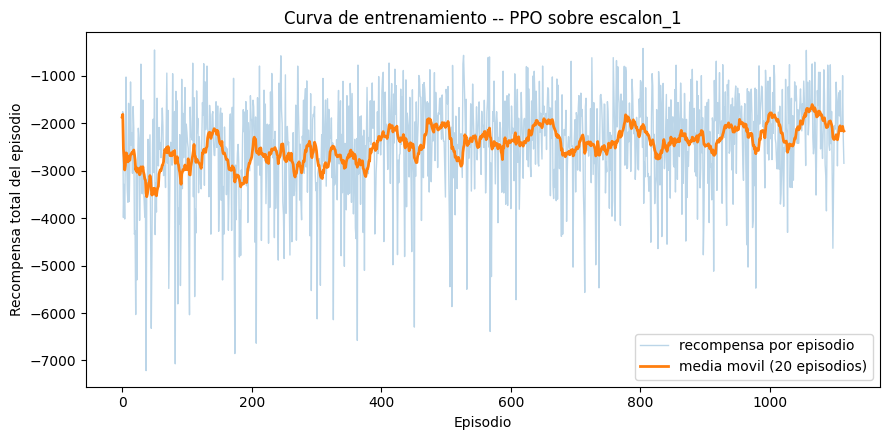

1115 episodios entrenados. Recompensa: primeros 20 = -2650.65, ultimos 20 = -2161.18


In [6]:
import matplotlib.pyplot as plt
from stable_baselines3.common.monitor import load_results
from stable_baselines3.common.results_plotter import ts2xy

resultados = load_results(str(OUT_DIR))
x, y = ts2xy(resultados, "episodes")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(x, y, alpha=0.3, linewidth=1, label="recompensa por episodio")
if len(y) >= 20:
    media_movil = pd.Series(y).rolling(20, min_periods=1).mean()
    ax.plot(x, media_movil, linewidth=2, label="media movil (20 episodios)")
ax.set_xlabel("Episodio")
ax.set_ylabel("Recompensa total del episodio")
ax.set_title(f"Curva de entrenamiento -- PPO sobre {cfg_entren['escalon_base']}")
ax.legend()
fig.tight_layout()
fig.savefig(OUT_DIR / "curva_entrenamiento.png", dpi=150)
plt.show()

print(f"{len(x)} episodios entrenados. Recompensa: primeros 20 = {y[:20].mean():.2f}, "
      f"ultimos 20 = {y[-20:].mean():.2f}")
